In [25]:
import os
import math
import concurrent.futures
import multiprocessing
import numpy as np
import pandas as pd
import xlwings as xw
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, truncnorm, norm, poisson, beta as beta_dist
from scipy.optimize import minimize
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

             Preco
Data              
1996-09-02  123.09
1996-09-03  119.68
1996-09-04  119.39
1996-09-05  118.42
1996-09-06  118.09
              Preco
Data               
2025-10-13  2219.96
2025-10-14  2301.24
2025-10-15  2314.21
2025-10-16  2269.67
2025-10-17  2262.88


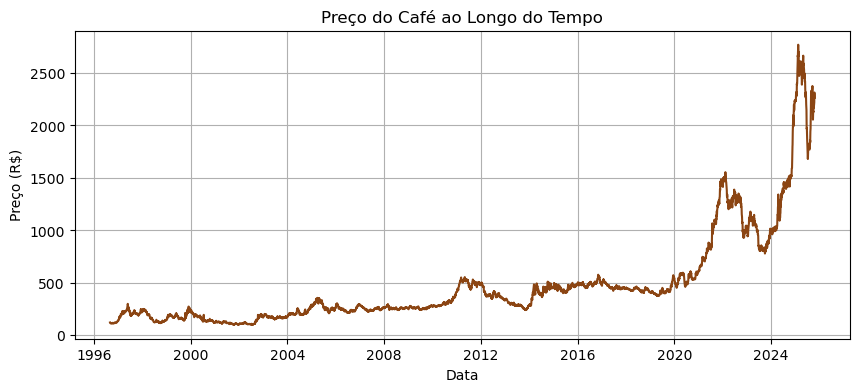

=== Estatísticas Descritivas ===
count    7255.000000
mean      474.544509
std       450.893020
min       101.480000
25%       218.190000
50%       310.620000
75%       489.195000
max      2769.450000

=== Estatísticas dos Retornos Logarítmicos ===
count    7254.000000
mean        0.000401
std         0.018661
min        -0.162006
25%        -0.008008
50%         0.000357
75%         0.008958
max         0.256636


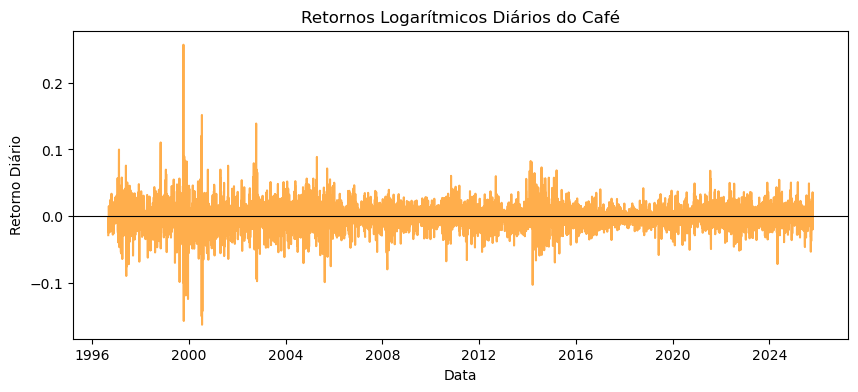

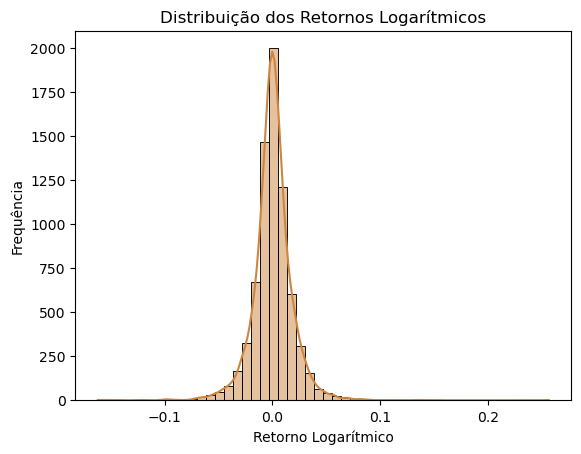

=== Medidas de Forma dos Retornos ===
Curtose (Kurtosis): 11.6924


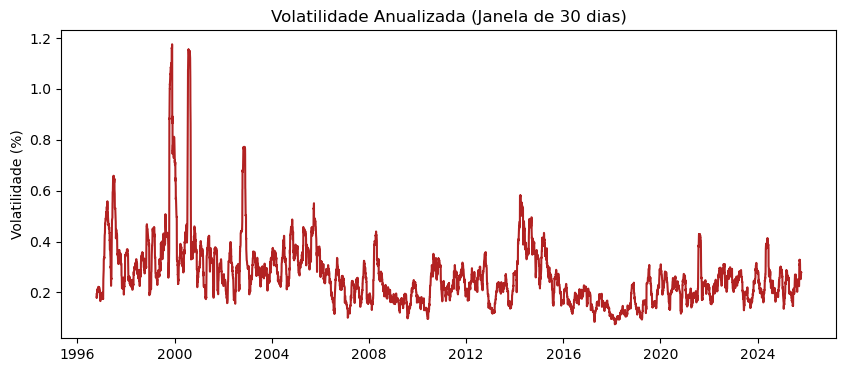


Resumo dos Retornos Logarítmicos:
                       0
Média           0.000401
Desvio-Padrão   0.018661
Assimetria      0.143039
Curtose        11.692431
Min            -0.162006
Max             0.256636


In [4]:
# Ler o arquivo Excel
df = pd.read_excel('Preços café.xls')
df.columns = ['Data', 'Preco']
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
df = df.sort_values('Data').set_index('Data')

# Visualizar início e fim da série
print(df.head())
print(df.tail())

# Plotar a série
plt.figure(figsize=(10,4))
plt.plot(df['Preco'], color='saddlebrown')
plt.title('Preço do Café ao Longo do Tempo')
plt.ylabel('Preço (R$)')
plt.xlabel('Data')
plt.grid(True)
plt.show()

# Estatísticas básicas
print("=== Estatísticas Descritivas ===")
print(df['Preco'].describe().to_string())

# Retornos logarítmicos
df['Retorno_Log'] = np.log(df['Preco'] / df['Preco'].shift(1))
print("\n=== Estatísticas dos Retornos Logarítmicos ===")
print(df['Retorno_Log'].describe().to_string())

# Plot dos retornos
plt.figure(figsize=(10,4))
plt.plot(df['Retorno_Log'], color='darkorange', alpha=0.7)
plt.title('Retornos Logarítmicos Diários do Café')
plt.ylabel('Retorno Diário')
plt.xlabel('Data')
plt.axhline(0, color='black', lw=0.8)
plt.show()

sns.histplot(df['Retorno_Log'].dropna(), bins=50, kde=True, color='peru')
plt.title('Distribuição dos Retornos Logarítmicos')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frequência')
plt.show()

print("=== Medidas de Forma dos Retornos ===")
print(f"Curtose (Kurtosis): {kurtosis(df['Retorno_Log'].dropna(), fisher=True):.4f}")

# Volatilidade móvel (desvio-padrão de 30 dias)
df['Volatilidade_30d'] = df['Retorno_Log'].rolling(window=30).std() * np.sqrt(252)  # anualizada
plt.figure(figsize=(10,4))
plt.plot(df['Volatilidade_30d'], color='firebrick')
plt.title('Volatilidade Anualizada (Janela de 30 dias)')
plt.ylabel('Volatilidade (%)')
plt.show()

summary = pd.DataFrame({
    'Média': [df['Retorno_Log'].mean()],
    'Desvio-Padrão': [df['Retorno_Log'].std()],
    'Assimetria': [skew(df['Retorno_Log'].dropna())],
    'Curtose': [kurtosis(df['Retorno_Log'].dropna(), fisher=True)],
    'Min': [df['Retorno_Log'].min()],
    'Max': [df['Retorno_Log'].max()]
})
print("\nResumo dos Retornos Logarítmicos:")
print(summary.T)

In [5]:
# ==============================================================
# 2. FUNÇÃO DE VEROSSIMILHANÇA (μ FIXO = 0)
# ==============================================================

retornos = df['Retorno_Log'].dropna().values

def merton_log_likelihood(params, data):
    sigma, lamb, mu_j, sigma_j = params
    mu = 0  # FIXO
    
    if sigma <= 0 or lamb < 0 or sigma_j <= 0:
        return 1e10
    
    dt = 1
    likelihood = 0
    
    for k in range(10):
        p_k = (np.exp(-lamb * dt) * (lamb * dt)**k) / math.factorial(k)
        
        mu_total = (mu - lamb * mu_j - 0.5 * sigma**2) * dt + k * mu_j
        var_total = (sigma**2 * dt) + k * (sigma_j**2)
        
        likelihood += p_k * norm.pdf(data, loc=mu_total, scale=np.sqrt(var_total))
    
    likelihood = np.maximum(likelihood, 1e-12)
    
    return -np.sum(np.log(likelihood))

# ==============================================================
# 3. ESTIMAÇÃO VIA MLE
# ==============================================================

initial_guess = [retornos.std(), 0.05, 0.0, retornos.std()*2]

result = minimize(
    merton_log_likelihood,
    initial_guess,
    args=(retornos,),
    method='L-BFGS-B',
    bounds=[
        (1e-6, None),  # sigma
        (1e-6, None),  # lambda (removi limite superior 1)
        (None, None),  # mu_j
        (1e-6, None)   # sigma_j
    ]
)

sigma_mle, lamb_mle, muj_mle, sigmaj_mle = result.x

# ==============================================================
# 4. RESULTADOS
# ==============================================================

print("---- Parâmetros Estimados via MLE (μ = 0 fixo) ----")
print(f"μ (drift): 0 (fixado)")
print(f"σ (volatilidade contínua): {sigma_mle:.6f}")
print(f"λ (intensidade de saltos): {lamb_mle:.6f}")
print(f"μ_j (média do salto): {muj_mle:.6f}")
print(f"σ_j (desvio do salto): {sigmaj_mle:.6f}")

---- Parâmetros Estimados via MLE (μ = 0 fixo) ----
μ (drift): 0 (fixado)
σ (volatilidade contínua): 0.008396
λ (intensidade de saltos): 0.642430
μ_j (média do salto): -0.000393
σ_j (desvio do salto): 0.019949


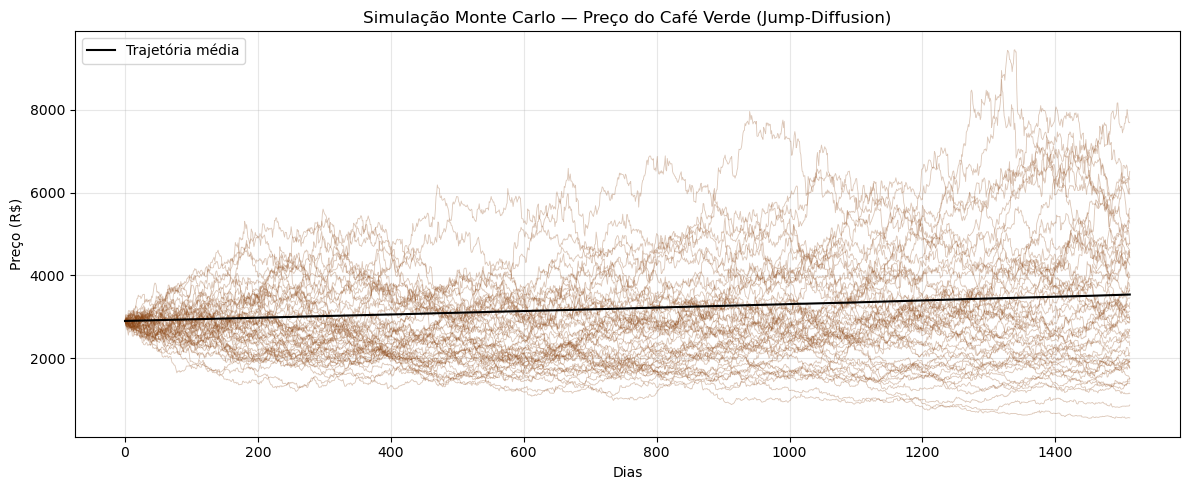


Parâmetros utilizados (escala diária):
  S0     = 2900.00
  σ      = 0.008396
  λ      = 0.642430
  μⱼ     = -0.000393
  σⱼ     = 0.019949
  Drift ajustado (μ - λμⱼ) = 0.000253

--- Preço de Venda (PERT) ---
  E(x) teórico = R$ 40.00
  E(x) simulado= R$ 39.9993
  Mín simulado = R$ 38.0072
  Máx simulado = R$ 41.9888


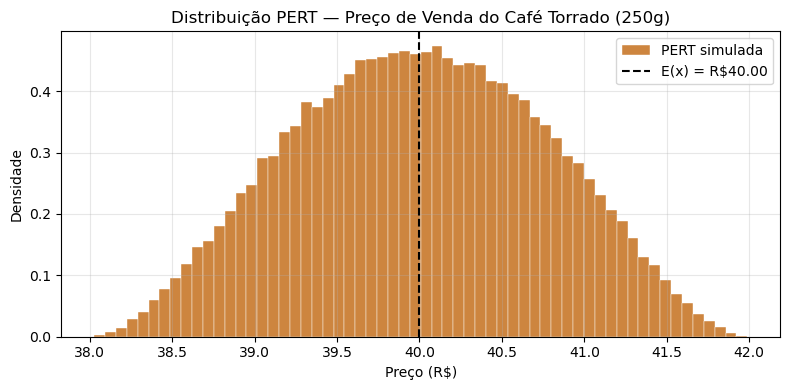


--- Quantidade Vendida (PERT crescente) ---
  Período  1: moda=3.0 | E(x) teórico=3.00 | E(x) simulado=3.0003
  Período 72: moda=13.0 | E(x) teórico=13.00 | E(x) simulado=13.0042


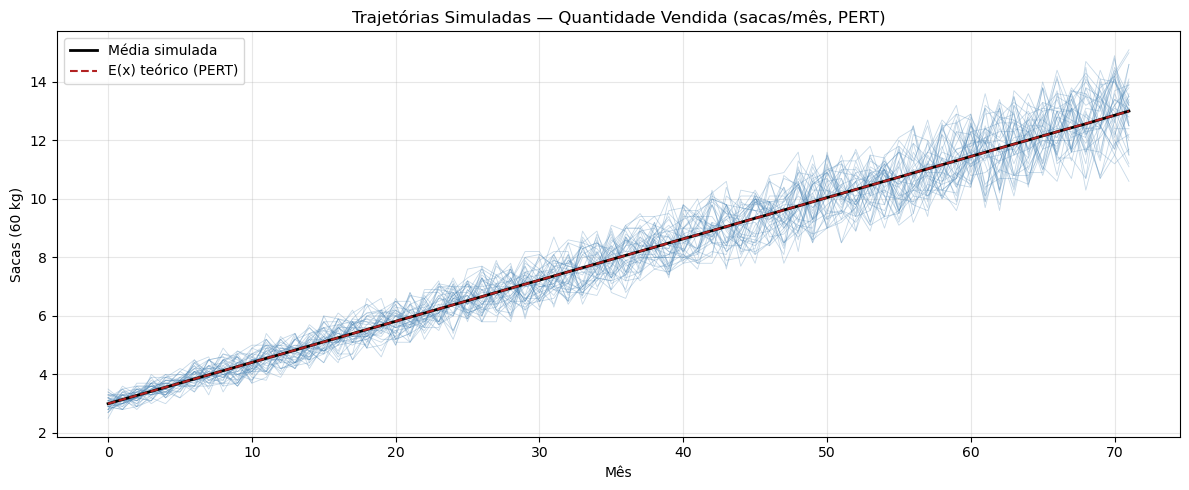

In [6]:
"""
=============================================================
MODELAGEM DAS 3 DISTRIBUIÇÕES - SIMULAÇÃO MONTE CARLO CAFÉ
=============================================================
Este módulo é um complemento ao notebook Simulação_Monte_Carlo.ipynb.
Assume que os parâmetros MLE (mu_mle, sigma_mle, lamb_mle, muj_mle,
sigmaj_mle) e o preço inicial (S0) já foram estimados nas células
anteriores do notebook.
 
CORREÇÕES aplicadas em relação ao código original:
  1. Preço de venda: triangular → PERT (Beta redimensionada)
  2. Quantidade vendida: triangular → PERT com limites ±20% da moda
  3. Adicionada simulação jump-diffusion que gera 'resultados'
  4. dt mantido em escala diária (consistente com MLE onde dt=1)
=============================================================
"""

 
# =============================================================
# FUNÇÃO AUXILIAR: DISTRIBUIÇÃO PERT
# =============================================================
 
def pert_rvs(a, m, b, size):
    """
    Amostra da distribuição PERT via Beta redimensionada.
 
    Parâmetros
    ----------
    a : float ou array — limite inferior
    m : float ou array — moda (valor mais provável)
    b : float ou array — limite superior
    size : int — número de amostras
 
    Retorna
    -------
    np.ndarray de shape (size,)
 
    Fórmula do valor esperado: E(x) = (a + 4m + b) / 6
    Shape parameters da Beta:
        alpha = 1 + 4*(m - a)/(b - a)
        beta  = 1 + 4*(b - m)/(b - a)
    """
    a, m, b = np.asarray(a, float), np.asarray(m, float), np.asarray(b, float)
    if np.any(b <= a):
        raise ValueError("Limite superior 'b' deve ser maior que 'a'.")
    if np.any((m < a) | (m > b)):
        raise ValueError("Moda 'm' deve estar entre 'a' e 'b'.")
 
    alpha = 1 + 4 * (m - a) / (b - a)
    beta  = 1 + 4 * (b - m) / (b - a)
 
    samples = beta_dist.rvs(alpha, beta, size=size)
    return a + (b - a) * samples
 
 
# =============================================================
# DISTRIBUIÇÃO 1: CAFÉ VERDE — JUMP-DIFFUSION (Merton, 1976)
# =============================================================
# NOTA: Esta seção deve ser executada APÓS a estimação MLE
# do notebook original, que gera:
#   sigma_mle, lamb_mle, muj_mle, sigmaj_mle
#
# Ajuste o S0 e n_simulacoes conforme seu contexto.
# =============================================================
 
def simular_jump_diffusion(S0, mu, sigma, lamb, mu_j, sigma_j,
                           n_dias, n_simulacoes, dt=1):
    """
    Simula trajetórias de preço pelo modelo Jump-Diffusion de Merton.
 
    Equação discreta:
        S[t+1] = S[t] * exp( drift_ajustado + sigma*sqrt(dt)*Z + J_t )
 
    Onde:
        drift_ajustado = (mu - lamb*mu_j - 0.5*sigma²) * dt
        J_t = soma de N_t saltos ~ Normal(mu_j, sigma_j)
        N_t ~ Poisson(lamb * dt)
 
    O ajuste (mu - lamb*mu_j) evita dupla contagem do impacto médio
    dos saltos, conforme Merton (1976) e descrito no texto.
 
    Parâmetros em escala DIÁRIA (consistente com MLE onde dt=1).
 
    Parâmetros
    ----------
    S0            : float — preço inicial do café verde
    mu            : float — drift diário estimado via MLE
    sigma         : float — volatilidade contínua diária
    lamb          : float — intensidade de saltos (saltos/dia)
    mu_j          : float — média do tamanho dos saltos (log)
    sigma_j       : float — desvio-padrão do tamanho dos saltos
    n_dias        : int   — número de dias a simular (ex: 6*252=1512)
    n_simulacoes  : int   — número de trajetórias Monte Carlo
    dt            : float — passo de tempo (1 = diário, padrão)
 
    Retorna
    -------
    resultados : np.ndarray de shape (n_simulacoes, n_dias + 1)
    """
    resultados = np.zeros((n_simulacoes, n_dias + 1))
    resultados[:, 0] = S0
 
    # Drift ajustado: remove a parcela média dos saltos para
    # evitar dupla contagem (Merton, 1976)
    drift_ajustado = (mu - lamb * mu_j - 0.5 * sigma**2) * dt
 
    for t in range(n_dias):
        # Componente browniano contínuo
        Z = np.random.standard_normal(n_simulacoes)
        difusao = sigma * np.sqrt(dt) * Z
 
        # Componente de saltos (Poisson + Normal)
        N_t = poisson.rvs(lamb * dt, size=n_simulacoes)
        J_t = np.zeros(n_simulacoes)
 
        idx_saltos = np.where(N_t > 0)[0]
        for i in idx_saltos:
            J_t[i] = np.sum(np.random.normal(mu_j, sigma_j, N_t[i]))
 
        log_retorno = drift_ajustado + difusao + J_t
        resultados[:, t + 1] = resultados[:, t] * np.exp(log_retorno)
 
    return resultados
 
 
# --- EXECUÇÃO ---
 
n_anos       = 6
n_dias_sim   = n_anos * 252          # 1512 dias úteis
n_simulacoes = 100000

S0 = 2900
 
resultados = simular_jump_diffusion(
    S0          = S0,
    mu          = 0,
    sigma       = sigma_mle,
    lamb        = lamb_mle,
    mu_j        = muj_mle,
    sigma_j     = sigmaj_mle,
    n_dias      = n_dias_sim,
    n_simulacoes= n_simulacoes
)
 
# Visualização de trajetórias
plt.figure(figsize=(12, 5))
for i in range(50):
    plt.plot(resultados[i], alpha=0.3, linewidth=0.6, color='saddlebrown')
plt.plot(resultados.mean(axis=0), color='black', linewidth=1.5,
         label='Trajetória média')
plt.title('Simulação Monte Carlo — Preço do Café Verde (Jump-Diffusion)')
plt.xlabel('Dias')
plt.ylabel('Preço (R$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"\nParâmetros utilizados (escala diária):")
print(f"  S0     = {S0:.2f}")
print(f"  σ      = {sigma_mle:.6f}")
print(f"  λ      = {lamb_mle:.6f}")
print(f"  μⱼ     = {muj_mle:.6f}")
print(f"  σⱼ     = {sigmaj_mle:.6f}")
print(f"  Drift ajustado (μ - λμⱼ) = {0 - lamb_mle*muj_mle:.6f}")
 
dias_por_mes = 21
n_meses = n_dias_sim // dias_por_mes

# =============================================================
# DISTRIBUIÇÃO 2: PREÇO DO CAFÉ TORRADO — PERT
# =============================================================
# CORREÇÃO: código original usava triangular. Substituído por PERT
# conforme metodologia descrita no texto.
#
# Parâmetros: a=38 (mínimo), m=40 (moda), b=42 (máximo)
# E(x) = (38 + 4*40 + 42) / 6 = 40.00
# =============================================================
 
a_venda = 38.0
m_venda = 40.0
b_venda = 42.0
 
# Gerado para cada simulação e cada mês
preco_venda = np.column_stack([
    pert_rvs(a_venda, m_venda, b_venda, size=n_simulacoes)
    for _ in range(n_meses)
])
 
# Valor esperado teórico
E_preco_venda = (a_venda + 4 * m_venda + b_venda) / 6
print(f"\n--- Preço de Venda (PERT) ---")
print(f"  E(x) teórico = R$ {E_preco_venda:.2f}")
print(f"  E(x) simulado= R$ {preco_venda.mean():.4f}")
print(f"  Mín simulado = R$ {preco_venda.min():.4f}")
print(f"  Máx simulado = R$ {preco_venda.max():.4f}")
 
# Histograma
plt.figure(figsize=(8, 4))
plt.hist(preco_venda[:, 0], bins=60, color='peru', edgecolor='white',
         linewidth=0.3, density=True, label='PERT simulada')
plt.axvline(E_preco_venda, color='black', linestyle='--',
            label=f'E(x) = R${E_preco_venda:.2f}')
plt.title('Distribuição PERT — Preço de Venda do Café Torrado (250g)')
plt.xlabel('Preço (R$)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
 
# =============================================================
# DISTRIBUIÇÃO 3: QUANTIDADE VENDIDA — PERT COM CRESCIMENTO
# =============================================================
# CORREÇÃO: código original usava truncnorm. Substituído por PERT
# conforme metodologia do texto.
#
# Crescimento: 3 sacas/mês (início) → 13 sacas/mês (6 anos)
# Variabilidade: ±20% da moda em cada período
#   a_t = 0.8 * moda_t
#   b_t = 1.2 * moda_t
# =============================================================
 
moda_inicial = 3.0
moda_final   = 13.0
 
moda_periodo = np.linspace(moda_inicial, moda_final, n_meses)
a_periodo    = 0.8 * moda_periodo   # limite inferior (-20%)
b_periodo    = 1.2 * moda_periodo   # limite superior (+20%)
 
quantidade = np.zeros((n_simulacoes, n_meses))
 
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a=a_periodo[t],
        m=moda_periodo[t],
        b=b_periodo[t],
        size=n_simulacoes
    )
 
quantidade = np.round(quantidade, 1)
 
# Valor esperado teórico por período: (a + 4m + b) / 6 = m (simétrico)
E_quantidade = (a_periodo + 4 * moda_periodo + b_periodo) / 6
 
print(f"\n--- Quantidade Vendida (PERT crescente) ---")
print(f"  Período  1: moda={moda_periodo[0]:.1f} | "
      f"E(x) teórico={E_quantidade[0]:.2f} | "
      f"E(x) simulado={quantidade[:, 0].mean():.4f}")
print(f"  Período {n_meses:2d}: moda={moda_periodo[-1]:.1f} | "
      f"E(x) teórico={E_quantidade[-1]:.2f} | "
      f"E(x) simulado={quantidade[:, -1].mean():.4f}")
 
# Trajetórias simuladas
plt.figure(figsize=(12, 5))
for i in range(40):
    plt.plot(quantidade[i], alpha=0.3, linewidth=0.6, color='steelblue')
plt.plot(quantidade.mean(axis=0), color='black', linewidth=2,
         label='Média simulada')
plt.plot(E_quantidade, color='firebrick', linewidth=1.5,
         linestyle='--', label='E(x) teórico (PERT)')
plt.title('Trajetórias Simuladas — Quantidade Vendida (sacas/mês, PERT)')
plt.xlabel('Mês')
plt.ylabel('Sacas (60 kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# CONFIGURAÇÕES
# -----------------------------
dias_por_mes = 21
arquivo_excel = "Modelagem Cafés Especiais Teste.xlsx"
aba_excel = "Distribuições"
celula_vpl = "C35"
n_sim = 1000

# DEFINA AQUI AS LINHAS CONTÍGUAS QUE VOCÊ RESERVOU NO EXCEL
# (Usaremos a coluna D como início, pois o seu modelo começa na coluna D)
range_precos_cafe = "D50"
range_quantidades = "D51"
range_precos_venda = "D52"

# -----------------------------
# CONECTAR AO EXCEL
# -----------------------------
wb = xw.Book(arquivo_excel)
sheet = wb.sheets[aba_excel]
app = wb.app
app.screen_updating = False
app.calculation = "manual"
app.display_alerts = False
app.enable_events = False

# -----------------------------
# PREPARAÇÃO DOS DADOS
# -----------------------------
traj = resultados[:n_sim]
n_sim_real = traj.shape[0]
n_dias = traj.shape[1]
n_meses = n_dias // dias_por_mes
traj = traj[:, : n_meses * dias_por_mes]

precos_mensais_all = traj.reshape(n_sim_real, n_meses, dias_por_mes).mean(
    axis=2
)
preco_medio_sim = precos_mensais_all.mean(axis=1)

preco_venda = np.column_stack(
    [pert_rvs(38.0, 40.0, 42.0, size=n_sim_real) for _ in range(n_meses)]
)

moda_periodo = np.linspace(3, 13, n_meses)
quantidade = np.zeros((n_sim_real, n_meses))
for t in range(n_meses):
    quantidade[:, t] = pert_rvs(
        a=0.8 * moda_periodo[t],
        m=moda_periodo[t],
        b=1.2 * moda_periodo[t],
        size=n_sim_real,
    )
quantidade = np.round(quantidade, 1)

# -----------------------------
# MONTE CARLO SUPER OTIMIZADO (1 ÚNICA CHAMADA DE ESCRITA)
# -----------------------------
vpl_resultados = []

for i in tqdm(range(n_sim_real), desc="Simulações Monte Carlo"):
    # Empilha os 3 arrays em uma matriz 2D de 3 linhas por 'n_meses' colunas
    matriz_input = np.vstack([
        precos_mensais_all[i, :], 
        quantidade[i, :], 
        preco_venda[i, :]
    ])
    
    # Faz apenas UMA chamada COM para preencher D50, D51 e D52 de uma vez
    sheet.range("D50").value = matriz_input

    # Recalcula e lê o resultado
    wb.app.calculate()
    vpl = sheet[celula_vpl].value
    
    if vpl is not None:
        vpl_resultados.append(float(vpl))

# -----------------------------
# FINALIZAR E RESTAURAR EXCEL
# -----------------------------
app.calculation = "automatic"
app.screen_updating = True
app.enable_events = True
vpl_resultados = np.array(vpl_resultados)

# -----------------------------
# RESULTADOS
# -----------------------------
print("VPL médio:", np.mean(vpl_resultados))
print("Probabilidade VPL negativo:", np.mean(vpl_resultados < 0))
print("Percentil 5%:", np.percentile(vpl_resultados, 5))
print("Percentil 95%:", np.percentile(vpl_resultados, 95))

tabela_vpl = pd.DataFrame(
    {
        "Simulação": np.arange(1, len(vpl_resultados) + 1),
        "VPL": vpl_resultados,
        "Preço médio do café": preco_medio_sim[: len(vpl_resultados)],
    }
)
print("\n=== Alguns VPLs simulados ===")
print(tabela_vpl.head())

# -----------------------------
# SALVAR DADOS PARA USO POSTERIOR
# -----------------------------
# Salvamos todas as matrizes estruturadas em um único arquivo binário compactado
np.savez_compressed(
    "dados_simulacao_cafe.npz",
    vpl_resultados=vpl_resultados,
    precos_mensais_all=precos_mensais_all,
    preco_venda=preco_venda,
    quantidade=quantidade,
    preco_medio_sim=preco_medio_sim
)
print("\n[Sucesso] Todos os arrays foram salvos em 'dados_simulacao_cafe.npz'")

Simulações Monte Carlo:   3%|▎         | 28/1000 [00:01<00:41, 23.44it/s]

In [20]:
# =============================================================================
# ANÁLISE DE SENSIBILIDADE
# Os arrays precos_mensais_all, preco_venda e quantidade já existem na memória
# com 1000 simulações — reutilizados diretamente, sem novos sorteios
# =============================================================================

# -----------------------------
# REATIVAR MODO MANUAL
# -----------------------------
app.screen_updating = False
app.calculation     = "manual"
app.display_alerts  = False
app.enable_events   = False

# -----------------------------
# FUNÇÕES
# -----------------------------
def rodar_simulacoes(pv, pt, q, desc):
    """Escreve inputs, recalcula e lê VPL. Retorna array de VPLs."""
    vpls = []
    for i in tqdm(range(pv.shape[0]), desc=desc):
        sheet.range(range_precos_cafe ).value = pv[i, :]
        sheet.range(range_quantidades ).value = q[i, :]
        sheet.range(range_precos_venda).value = pt[i, :]
        wb.app.calculate()
        v = sheet[celula_vpl].value
        if v is not None:
            vpls.append(float(v))
    return np.array(vpls)


def rodar_sensibilidade():
    """
    Perturba ±10% em cada variável usando os mesmos 1000 arrays da base.
    Retorna DataFrame com impactos ordenados por magnitude.
    """
    # VPL base da sensibilidade — mesmos arrays, sem perturbação
    vpl_base_sens = rodar_simulacoes(
        precos_mensais_all, preco_venda, quantidade,
        desc="Sensibilidade — base"
    )
    media_base = vpl_base_sens.mean()

    variaveis = [
        ("Preço café torrado", "torrado"),
        ("Preço café verde",   "verde"),
        ("Volume vendido",     "qtd"),
    ]

    linhas = []
    for label, chave in variaveis:
        vpls = {}
        for fator in (0.90, 1.10):
            pv_f = precos_mensais_all * (fator if chave == "verde"   else 1.0)
            pt_f = preco_venda        * (fator if chave == "torrado" else 1.0)
            q_f  = quantidade         * (fator if chave == "qtd"     else 1.0)
            vpls[fator] = rodar_simulacoes(
                pv_f, pt_f, q_f,
                desc=f"Sens. {label} {fator-1:+.0%}"
            ).mean()

        linhas.append({
            "Variável"      : label,
            "VPL −10% (R$)" : vpls[0.90],
            "VPL base (R$)" : media_base,
            "VPL +10% (R$)" : vpls[1.10],
            "Δ −10%"        : (vpls[0.90] - media_base) / abs(media_base) * 100,
            "Δ +10%"        : (vpls[1.10] - media_base) / abs(media_base) * 100,
        })

    return (pd.DataFrame(linhas)
              .sort_values("Δ +10%", key=abs, ascending=False)
              .reset_index(drop=True))

# -----------------------------
# EXECUTAR
# -----------------------------
try:
    print(f"\n=== SENSIBILIDADE (1.000 simulações) ===")
    df_sens = rodar_sensibilidade()

    fmt = {
        "VPL −10% (R$)": lambda x: f"R$ {x:>12,.0f}",
        "VPL base (R$)": lambda x: f"R$ {x:>12,.0f}",
        "VPL +10% (R$)": lambda x: f"R$ {x:>12,.0f}",
        "Δ −10%"       : lambda x: f"{x:>+8.1f}%",
        "Δ +10%"       : lambda x: f"{x:>+8.1f}%",
    }
    print("\n")
    print(df_sens.to_string(index=False, formatters=fmt))

    # Exportar
    with pd.ExcelWriter("sensibilidade.xlsx", engine="openpyxl") as writer:
        df_sens.to_excel(writer, sheet_name="Sensibilidade", index=False)
    print("\n[Excel] sensibilidade.xlsx salvo.")

finally:
    app.calculation     = "automatic"
    app.screen_updating = True
    app.enable_events   = True
    app.display_alerts  = True
    print("[Excel] configurações restauradas.")


=== SENSIBILIDADE (1.000 simulações) ===


Sens. Volume vendido +10%: 100%|██████████| 1000/1000 [01:46<00:00,  9.39it/s]



          Variável   VPL −10% (R$)   VPL base (R$)   VPL +10% (R$)    Δ −10%    Δ +10%
Preço café torrado R$     -106,963 R$      119,923 R$      347,431   -189.2%   +189.7%
  Preço café verde R$      251,604 R$      119,923 R$      -11,757   +109.8%   -109.8%
    Volume vendido R$       55,177 R$      119,923 R$      185,291    -54.0%    +54.5%

[Excel] sensibilidade.xlsx salvo.
[Excel] configurações restauradas.
